In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

file_path = "/content/drive/MyDrive/clash_royale_reviews.csv"

df = pd.read_csv(
    file_path,
    usecols=["review_id", "content", "score", "at", "likes", "appVersion"],
    parse_dates=["at"]
)

In [3]:
df["review_category"] = np.where(df["score"] >= 3, "positive", "negative")

In [ ]:
df["at"] = pd.to_datetime(df["at"])

In [ ]:
prelude_to_chaos = df[
    (df["at"] < "2021-10-01")
]
champions_df = df[
    (df["at"] >= "2021-10-01") &
    (df["at"] < "2023-6-01")
]
evos_df = df[
    (df["at"] >= "2023-6-01") &
    (df["at"] < "2025-12-01")
]
heros_df = df[
    (df["at"] >= "2025-12-01")
]

In [ ]:
print(prelude_to_chaos["review_category"].value_counts())
print(champions_df["review_category"].value_counts())
print(evos_df["review_category"].value_counts())
print(heros_df["review_category"].value_counts())

review_category
positive    1678127
negative     226985
Name: count, dtype: int64
review_category
positive    146114
negative     60930
Name: count, dtype: int64
review_category
positive    103104
negative     73508
Name: count, dtype: int64
review_category
positive    10059
negative     8269
Name: count, dtype: int64


In [ ]:
print((prelude_to_chaos["review_category"] == "positive").mean())
print((champions_df["review_category"] == "positive").mean())
print((evos_df["review_category"] == "positive").mean())
print((heros_df["review_category"] == "positive").mean())

0.8808547738925585
0.7057147273043411
0.5837881910628949
0.5488323876036665


In [ ]:
#Sample for "Prelude" Clash
positive_df_prelude = prelude_to_chaos[prelude_to_chaos['review_category'] == 'positive']
negative_df_prelude = prelude_to_chaos[prelude_to_chaos['review_category'] == 'negative']

prelude_pos_sample = positive_df_prelude.sample(n=100000, random_state=123)
prelude_neg_sample = negative_df_prelude.sample(n=100000, random_state=123)

smaller_samplePrelude = (
    pd.concat([prelude_pos_sample, prelude_neg_sample])
    .sample(frac=1, random_state=123)
    .reset_index(drop=True)
)

In [ ]:
#Sample for Champions Update Clash
positive_df_champions = champions_df[champions_df['review_category'] == 'positive']
negative_df_champions = champions_df[champions_df['review_category'] == 'negative']

champions_pos_sample = positive_df_champions.sample(n=40000, random_state=123)
champions_neg_sample = negative_df_champions.sample(n=40000, random_state=123)

smaller_sampleChampions = (pd.concat([champions_pos_sample, champions_neg_sample])
    .sample(frac=1, random_state=123)
    .reset_index(drop=True)
)

In [ ]:
#Sample for Evo Update Clash
positive_df_evos = evos_df[evos_df['review_category'] == 'positive']
negative_df_evos = evos_df[evos_df['review_category'] == 'negative']

evos_pos_sample = positive_df_evos.sample(n=50000, random_state=123)
evos_neg_sample = negative_df_evos.sample(n=50000, random_state=123)

smaller_sampleEvos = (pd.concat([evos_pos_sample, evos_neg_sample])
    .sample(frac=1, random_state=123)
    .reset_index(drop=True)
)

In [ ]:
#Sample for Hero Update Clash
positive_df_heros = heros_df[heros_df['review_category'] == 'positive']
negative_df_heros = heros_df[heros_df['review_category'] == 'negative']

heros_pos_sample = positive_df_heros.sample(n=5000, random_state=123)
heros_neg_sample = negative_df_heros.sample(n=5000, random_state=123)

smaller_sampleHeros = (pd.concat([heros_pos_sample, heros_neg_sample])
    .sample(frac=1, random_state=123)
    .reset_index(drop=True)
)

In [ ]:
classify_prelude_df = pd.DataFrame(data = smaller_samplePrelude)
classify_prelude_df = classify_prelude_df[classify_prelude_df.columns[[1,6]]]

classify_champions_df = pd.DataFrame(data = smaller_sampleChampions)
classify_champions_df = classify_champions_df[classify_champions_df.columns[[1,6]]]

classify_evos_df = pd.DataFrame(data = smaller_sampleEvos)
classify_evos_df = classify_evos_df[classify_evos_df.columns[[1,6]]]

classify_heros_df = pd.DataFrame(data = smaller_sampleHeros)
classify_heros_df = classify_heros_df[classify_heros_df.columns[[1,6]]]

In [ ]:
from sklearn.model_selection import train_test_split

#For Reviews Prior to Champions:
X_train, X_test, y_train, y_test = train_test_split(classify_prelude_df['content'], classify_prelude_df['review_category'], test_size = 0.2, random_state=123)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn import metrics


text_clf = Pipeline([('vect', CountVectorizer(min_df = 0.001, max_df = 0.9)),
                     ('clf', LogisticRegression(random_state=123, solver='newton-cg')),
])

text_clf.fit(X_train.values.astype('U'), y_train.values.astype('U'))

predicted = text_clf.predict(X_test)

print(metrics.classification_report(y_test, predicted))



KeyboardInterrupt: 

In [ ]:
feature_names_lr = text_clf['vect'].get_feature_names_out()
coefficients_lr = text_clf['clf'].coef_[0]


feature_coefficients_series = pd.Series(coefficients_lr, index=feature_names_lr)

coef_df = (
    pd.DataFrame({
        'word': feature_names_lr,
        'coefficient': coefficients_lr
    }))
coef_df['sentiment'] = np.where(
    coef_df['coefficient'] > 0,
    'positive',
    'negative')


top_positive = (
    coef_df[coef_df['coefficient'] > 0]
    .sort_values(by='coefficient', ascending=False)
    .head(25)
)
top_negative = (
    coef_df[coef_df['coefficient'] < 0]
    .sort_values(by='coefficient', ascending=True)
    .head(25)
)
presentable_df = pd.concat(
    [
        top_positive[['word', 'coefficient']].reset_index(drop=True),
        top_negative[['word', 'coefficient']].reset_index(drop=True)
    ],
    axis=1,
    keys=['Positive indicators', 'Negative indicators']
)

presentable_df

Positive indicators             Negative indicators            
                  word coefficient                word coefficient
0              awesome    2.787855               worst   -3.216608
1               awsome    2.541747            horrible   -3.061250
2              amazing    2.479565               trash   -2.976527
3               superb    2.405073               hated   -2.930566
4            addicting    2.212040               sucks   -2.579195
5                 best    2.210507             garbage   -2.559779
6            fantastic    2.199475            bullshit   -2.355375
7            excellent    2.142280             rubbish   -2.343308
8                 love    2.140865              stupid   -2.303169
9                great    2.108736               awful   -2.256255
10            favorite    2.027035          unbalanced   -2.208763
11                cool    2.009216                dead   -2.179911
12           favourite    1.975050            retarded   -2.150499
13           wonderful    1.933067                hate   -2.127684
14               loved    1.905999              ruined   -2.120631
15            addicted    1.791850                noob   -2.103121
16           addictive    1.780599              rigged   -2.074647
17        entertaining    1.773269                crap   -2.068347
18           beautiful    1.596116          unplayable   -2.058333
19                nice    1.592437                dumb   -2.052156
20             perfect    1.580257               worse   -2.021329
21                 fun    1.552783               waste   -1.944686
22                good    1.385000            terrible   -1.870511
23              killer    1.327524                poor   -1.857139
24           strategic    1.307338                suck   -1.839063

In [ ]:
#For Reviews Between Champions and Evos:

X_train, X_test, y_train, y_test = train_test_split(classify_champions_df['content'], classify_champions_df['review_category'], test_size = 0.2, random_state=123)

text_clf = Pipeline([('vect', CountVectorizer(min_df = 0.001, max_df = 0.9)),
                     ('clf', LogisticRegression(random_state=123, solver='newton-cg')),
])

text_clf.fit(X_train.values.astype('U'), y_train.values.astype('U'))

predicted = text_clf.predict(X_test)

print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

    negative       0.87      0.79      0.83      7979
    positive       0.81      0.88      0.84      8021

    accuracy                           0.84     16000
   macro avg       0.84      0.84      0.84     16000
weighted avg       0.84      0.84      0.84     16000



In [ ]:
feature_names_lr = text_clf['vect'].get_feature_names_out()
coefficients_lr = text_clf['clf'].coef_[0]


feature_coefficients_series = pd.Series(coefficients_lr, index=feature_names_lr)

coef_df = (
    pd.DataFrame({
        'word': feature_names_lr,
        'coefficient': coefficients_lr
    }))
coef_df['sentiment'] = np.where(
    coef_df['coefficient'] > 0,
    'positive',
    'negative')


top_positive = (
    coef_df[coef_df['coefficient'] > 0]
    .sort_values(by='coefficient', ascending=False)
    .head(25)
)
top_negative = (
    coef_df[coef_df['coefficient'] < 0]
    .sort_values(by='coefficient', ascending=True)
    .head(25)
)
presentable_df = pd.concat(
    [
        top_positive[['word', 'coefficient']].reset_index(drop=True),
        top_negative[['word', 'coefficient']].reset_index(drop=True)
    ],
    axis=1,
    keys=['Positive indicators', 'Negative indicators']
)

presentable_df

Positive indicators             Negative indicators            
                  word coefficient                word coefficient
0              amazing    2.617204                lgbt   -3.031733
1                noice    2.325349              greedy   -2.821541
2            excellent    2.275252               worst   -2.566798
3                 cool    2.168993             dogshit   -2.538406
4               awsome    2.164294             garbage   -2.464059
5                 best    2.145224            horrible   -2.426144
6                great    2.048692              ruined   -2.415274
7              awesome    2.025613             rubbish   -2.304424
8         entertaining    2.016221              killed   -2.296648
9            fantastic    1.936505               greed   -2.282946
10                love    1.935413               trash   -2.247273
11            addicted    1.931188                poor   -2.101065
12              superb    1.860381             crashes   -2.007689
13           wonderful    1.745178                scam   -2.005098
14                 gud    1.723360            terrible   -1.975984
15                عالی    1.722891                devs   -1.867602
16                nice    1.703312               sucks   -1.850702
17           favourite    1.668135          disgusting   -1.819700
18                good    1.644642             pay2win   -1.780678
19            favorite    1.445071          unbalanced   -1.761765
20             perfect    1.426880               waste   -1.750655
21                epic    1.421521       disappointing   -1.696225
22                 fun    1.378567              banned   -1.694277
23               happy    1.365055              stupid   -1.685729
24                 yes    1.344967                grab   -1.616380

In [ ]:
#For Reviews Between Evos and Heros:

X_train, X_test, y_train, y_test = train_test_split(classify_evos_df['content'], classify_evos_df['review_category'], test_size = 0.2, random_state=123)

text_clf = Pipeline([('vect', CountVectorizer(min_df = 0.001, max_df = 0.9)),
                     ('clf', LogisticRegression(random_state=123, solver='newton-cg')),
])

text_clf.fit(X_train.values.astype('U'), y_train.values.astype('U'))

predicted = text_clf.predict(X_test)

print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

    negative       0.87      0.82      0.84      9969
    positive       0.83      0.88      0.85     10031

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



In [ ]:
feature_names_lr = text_clf['vect'].get_feature_names_out()
coefficients_lr = text_clf['clf'].coef_[0]


feature_coefficients_series = pd.Series(coefficients_lr, index=feature_names_lr)

coef_df = (
    pd.DataFrame({
        'word': feature_names_lr,
        'coefficient': coefficients_lr
    }))
coef_df['sentiment'] = np.where(
    coef_df['coefficient'] > 0,
    'positive',
    'negative')


top_positive = (
    coef_df[coef_df['coefficient'] > 0]
    .sort_values(by='coefficient', ascending=False)
    .head(25)
)
top_negative = (
    coef_df[coef_df['coefficient'] < 0]
    .sort_values(by='coefficient', ascending=True)
    .head(25)
)
presentable_df = pd.concat(
    [
        top_positive[['word', 'coefficient']].reset_index(drop=True),
        top_negative[['word', 'coefficient']].reset_index(drop=True)
    ],
    axis=1,
    keys=['Positive indicators', 'Negative indicators']
)

presentable_df

Positive indicators             Negative indicators            
                  word coefficient                word coefficient
0                 peak    2.827706             garbage   -2.847739
1               goated    2.651817               greed   -2.628862
2                 tuff    2.600657        uninstalling   -2.617475
3             greatest    2.430795               worst   -2.562391
4              amazing    2.424695              ruined   -2.400481
5                 عالی    2.415277               trash   -2.369397
6            excellent    2.409344                poor   -2.248494
7                 best    2.237011            downhill   -2.112754
8            fantastic    2.188247              greedy   -2.108963
9              awesome    2.074832              killed   -2.068442
10                love    2.035567            horrible   -2.038654
11                nice    1.975747          disgusting   -2.023681
12               great    1.975213               sucks   -1.958048
13               sigma    1.960293               waste   -1.937462
14           wonderful    1.889525            pathetic   -1.928249
15                cool    1.887490            cheaters   -1.894063
16             perfect    1.759171            terrible   -1.846476
17                 gud    1.733927             pay2win   -1.832574
18        entertaining    1.720858             company   -1.797906
19                good    1.720574                rare   -1.757823
20         interesting    1.625633                zero   -1.743864
21            favorite    1.533356            removing   -1.739788
22            heheheha    1.513051                rich   -1.739547
23              unique    1.511423                grab   -1.721818
24             mention    1.499572             ruining   -1.718808

In [ ]:
#For Reviews From the Hero Update Onward:
X_train, X_test, y_train, y_test = train_test_split(classify_heros_df['content'], classify_heros_df['review_category'], test_size = 0.2, random_state=123)

text_clf = Pipeline([('vect', CountVectorizer(min_df = 0.001, max_df = 0.9)),
                     ('clf', LogisticRegression(random_state=123, solver='newton-cg')),
])

text_clf.fit(X_train.values.astype('U'), y_train.values.astype('U'))

predicted = text_clf.predict(X_test)

print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

    negative       0.87      0.84      0.86      1019
    positive       0.84      0.87      0.86       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



In [ ]:
feature_names_lr = text_clf['vect'].get_feature_names_out()
coefficients_lr = text_clf['clf'].coef_[0]


feature_coefficients_series = pd.Series(coefficients_lr, index=feature_names_lr)

coef_df = (
    pd.DataFrame({
        'word': feature_names_lr,
        'coefficient': coefficients_lr
    }))
coef_df['sentiment'] = np.where(
    coef_df['coefficient'] > 0,
    'positive',
    'negative')


top_positive = (
    coef_df[coef_df['coefficient'] > 0]
    .sort_values(by='coefficient', ascending=False)
    .head(25)
)
top_negative = (
    coef_df[coef_df['coefficient'] < 0]
    .sort_values(by='coefficient', ascending=True)
    .head(25)
)
presentable_df = pd.concat(
    [
        top_positive[['word', 'coefficient']].reset_index(drop=True),
        top_negative[['word', 'coefficient']].reset_index(drop=True)
    ],
    axis=1,
    keys=['Positive indicators', 'Negative indicators']
)

presentable_df

Positive indicators             Negative indicators            
                  word coefficient                word coefficient
0                 best    2.841826               trash   -2.696184
1              amazing    2.491168               greed   -2.539326
2                 love    2.372399              greedy   -2.448797
3                 peak    2.366919             garbage   -2.437669
4                 nice    2.324007               worst   -2.194414
5                great    2.264666                cash   -1.968303
6                early    2.244613              killed   -1.914805
7                 good    2.119594             anymore   -1.778884
8             addicted    2.060885          greedycell   -1.743631
9                 cool    1.879681            terrible   -1.698885
10                tuff    1.833990              bought   -1.695556
11             overall    1.798156                scam   -1.680433
12              goated    1.782552               awful   -1.673362
13                  ok    1.776624               sucks   -1.671179
14                 fun    1.722334              unfair   -1.604654
15           addicting    1.595155          unbalanced   -1.573221
16             awesome    1.561692               toxic   -1.556344
17                 ads    1.558754             pay2win   -1.489701
18                also    1.557001            crashing   -1.451673
19                 tho    1.505459          unplayable   -1.440122
20            starting    1.479145            cheaters   -1.424227
21                  yo    1.413951        monetization   -1.406238
22                 set    1.383451             network   -1.385599
23        entertaining    1.346502              reward   -1.382199
24             perfect    1.328244            horrible   -1.369020

In [ ]:
#For common words
positive_reviews_prelude = classify_prelude_df[classify_prelude_df['review_category'] == 'positive']
negative_reviews_prelude = classify_prelude_df[classify_prelude_df['review_category'] == 'negative']

positive_reviews_champions = classify_champions_df[classify_champions_df['review_category'] == 'positive']
negative_reviews_champions = classify_champions_df[classify_champions_df['review_category'] == 'negative']

positive_reviews_evos = classify_evos_df[classify_evos_df['review_category'] == 'positive']
negative_reviews_evos = classify_evos_df[classify_evos_df['review_category'] == 'negative']

positive_reviews_heros = classify_heros_df[classify_heros_df['review_category'] == 'positive']
negative_reviews_heros = classify_heros_df[classify_heros_df['review_category'] == 'negative']



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

In [ ]:
#Common Words: Prelude
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words=list(ENGLISH_STOP_WORDS) + ['game'] + ['t'] + ['s'],
    token_pattern=r"[A-Za-z0-9]+"
)

X_posP = vectorizer.fit_transform(positive_reviews_prelude['content'].values.astype('U'))

prelude_pos = X_posP.toarray().sum(axis=0)

prelude_pos = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': prelude_pos
})

prelude_pos = prelude_pos.sort_values(by='count', ascending=False)

print(prelude_pos.head(20))



            word  count
9047        good  17330
12837       love   9764
2979        best   9360
8344         fun   8691
9290       great   7102
14461       nice   7063
2254     awesome   6226
12519       like   6034
15965       play   5911
20622       time   4348
4426       clash   4027
16987     really   3579
4975        cool   3556
1473     amazing   3496
11410       just   3095
19753  supercell   2937
942    addictive   2788
3918       cards   2669
8555       games   2475
4244       chest   2295


In [ ]:
X_neg = vectorizer.fit_transform(negative_reviews_prelude['content'].values.astype('U'))

word_counts_neg = X_neg.toarray().sum(axis=0)

words_neg = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': word_counts_neg
})

words_neg = words_neg.sort_values(by='count', ascending=False)

print(words_neg.head(20))

            word  count
21290      level  13648
27666       play  12506
6913       cards  11263
39176        win  10991
35905       time   9518
19527       just   9300
15795       good   8083
26858        pay   7961
21437       like   7481
27116     people   7035
23821      money   6976
11321        don   6864
37686     update   6673
14053        fix   6670
4278         bad   6046
22749      match   5721
27688    players   5672
34445  supercell   5610
27708    playing   5396
36980          u   5373


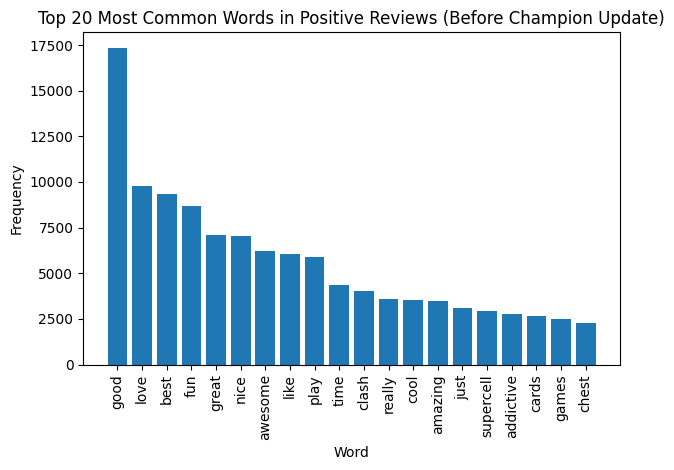

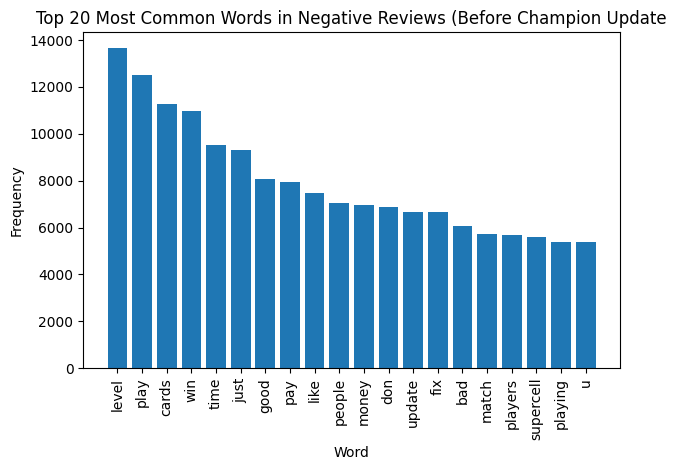

In [ ]:
import matplotlib.pyplot as plt

top_pos = prelude_pos.head(20)

plt.figure()
plt.bar(top_pos['word'], top_pos['count'])
plt.xticks(rotation=90)
plt.title("Top 20 Most Common Words in Positive Reviews (Before Champion Update)")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

top_neg = words_neg.head(20)

plt.figure()
plt.bar(top_neg['word'], top_neg['count'])
plt.xticks(rotation=90)
plt.title("Top 20 Most Common Words in Negative Reviews (Before Champion Update")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
#Champions Update
X_pos = vectorizer.fit_transform(positive_reviews_champions['content'].values.astype('U'))

X_pos = X_pos.toarray().sum(axis=0)

X_pos = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X_pos
})

X_pos = X_pos.sort_values(by='count', ascending=False)

print(X_pos.head(20))

          word  count
5989      good   8752
5511       fun   5057
1748      best   3091
10787     play   2768
8465      love   2643
6148     great   2494
9639      nice   2295
8275      like   2218
7648      just   1844
11556   really   1822
2383     cards   1542
8214     level   1423
15318      win   1412
10806  playing   1327
14102     time   1289
14688   update   1225
845    amazing   1223
10456      pay   1172
2740     clash    980
10551   people    980


In [ ]:
X_neg = vectorizer.fit_transform(negative_reviews_champions['content'].values.astype('U'))

word_counts_neg = X_neg.toarray().sum(axis=0)

words_neg = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': word_counts_neg
})

words_neg = words_neg.sort_values(by='count', ascending=False)

print(words_neg.head(20))

              word  count
22390          win   7277
11939        level   7268
21548       update   6372
3662         cards   6165
15097          pay   6080
15561         play   5807
11045         just   4960
15578      players   3199
12034         like   3092
15236       people   3086
20480         time   3080
8310           fun   3072
8910          good   3053
6222           don   3025
13424        money   2916
2238           bad   2831
13949          new   2760
12795  matchmaking   2734
15589      playing   2650
1785         arena   2507


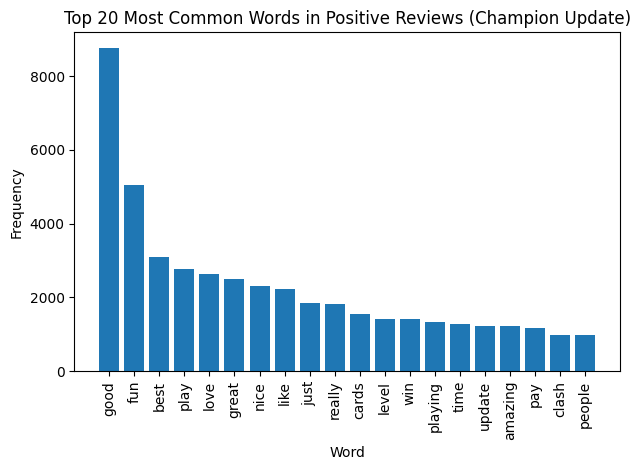

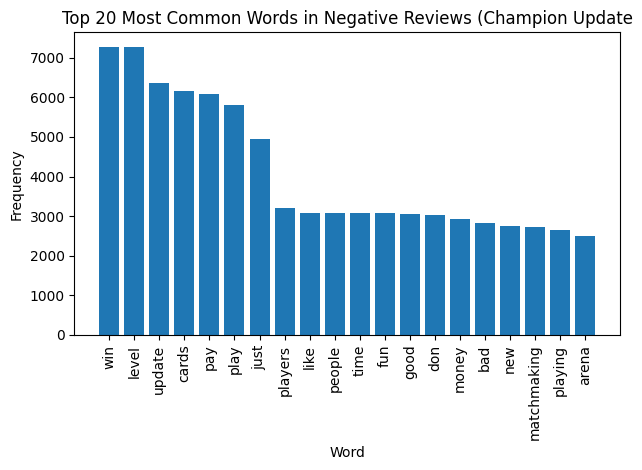

In [ ]:
top_pos = X_pos.head(20)

plt.figure()
plt.bar(top_pos['word'], top_pos['count'])
plt.xticks(rotation=90)
plt.title("Top 20 Most Common Words in Positive Reviews (Champion Update)")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

top_neg = words_neg.head(20)

plt.figure()
plt.bar(top_neg['word'], top_neg['count'])
plt.xticks(rotation=90)
plt.title("Top 20 Most Common Words in Negative Reviews (Champion Update")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
#Evolution Update
X_pos = vectorizer.fit_transform(positive_reviews_evos['content'].values.astype('U'))

X_pos = X_pos.toarray().sum(axis=0)

X_pos = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X_pos
})

X_pos = X_pos.sort_values(by='count', ascending=False)

print(X_pos.head(20))

          word  count
7086      good  10646
6503       fun   6279
2151      best   4217
9926      love   3627
12600     play   3592
7306     great   2785
17817      win   2714
11319     nice   2647
9703      like   2634
12245      pay   2451
8969      just   2188
13451   really   2001
12617  playing   1820
3277     clash   1768
16427     time   1540
1108   amazing   1504
2867     cards   1464
6666     games   1116
9634     level   1078
18112    years   1042


In [ ]:
X_neg = vectorizer.fit_transform(negative_reviews_evos['content'].values.astype('U'))

word_counts_neg = X_neg.toarray().sum(axis=0)

words_neg = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': word_counts_neg
})

words_neg = words_neg.sort_values(by='count', ascending=False)

print(words_neg.head(20))

            word  count
25825        win  15012
17328        pay  14377
17875       play   8107
12633       just   7311
4070       cards   6952
13546      level   6780
15317      money   6375
24846     update   5603
7116         don   4527
17896    players   4475
9569         fun   4187
23616       time   4122
17914    playing   3994
10235       good   3965
13648       like   3906
15951        new   3511
22747  supercell   3405
4065        card   3266
17494     people   3189
25986      worst   3179


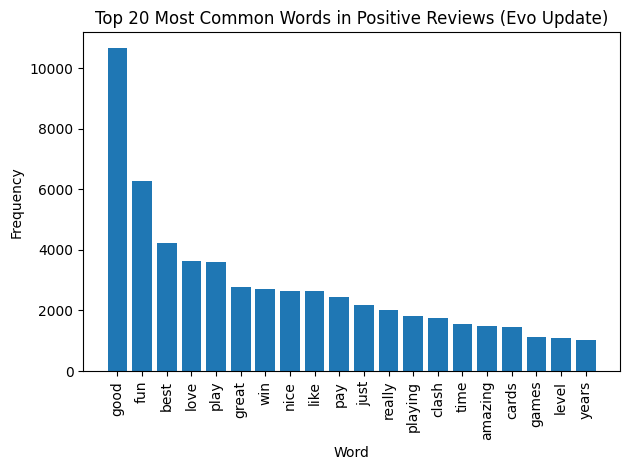

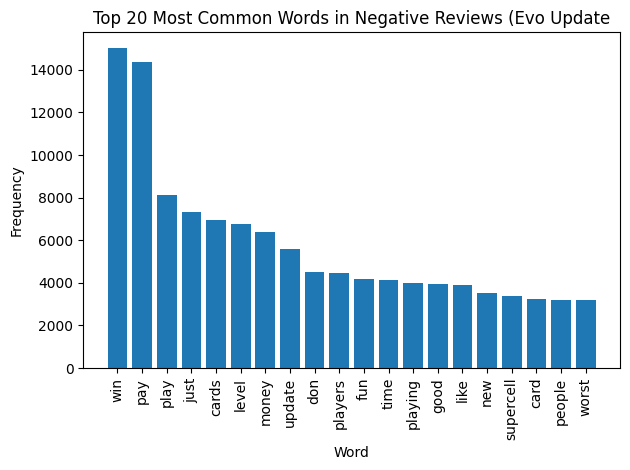

In [ ]:
top_pos = X_pos.head(20)

plt.figure()
plt.bar(top_pos['word'], top_pos['count'])
plt.xticks(rotation=90)
plt.title("Top 20 Most Common Words in Positive Reviews (Evo Update)")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

top_neg = words_neg.head(20)

plt.figure()
plt.bar(top_neg['word'], top_neg['count'])
plt.xticks(rotation=90)
plt.title("Top 20 Most Common Words in Negative Reviews (Evo Update")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
#Hero Update
X_pos = vectorizer.fit_transform(positive_reviews_heros['content'].values.astype('U'))

X_pos = X_pos.toarray().sum(axis=0)

X_pos = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X_pos
})

X_pos = X_pos.sort_values(by='count', ascending=False)

print(X_pos.head(20))

         word  count
1677     good   1090
1536      fun    989
481      best    485
4065      win    410
2884     play    402
2301     love    382
2809      pay    380
2240     like    309
1726    great    299
3094   really    282
2080     just    254
764     clash    222
282   amazing    197
2892  playing    182
2619     nice    173
3752     time    159
2759      p2w    157
665     cards    155
1583    games    137
2226    level    126


In [ ]:
X_neg = vectorizer.fit_transform(negative_reviews_heros['content'].values.astype('U'))

word_counts_neg = X_neg.toarray().sum(axis=0)

words_neg = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': word_counts_neg
})

words_neg = words_neg.sort_values(by='count', ascending=False)

print(words_neg.head(20))

           word  count
6955        win   1772
4640        pay   1713
4772       play    890
3484       just    870
4178      money    867
3673      level    805
1052      cards    693
6708     update    584
4779    players    521
2624        fun    473
1926        don    469
4561        p2w    431
4306        new    421
52           16    421
3696       like    408
6383       time    401
4781    playing    377
2801       good    359
6129  supercell    348
4681     people    341


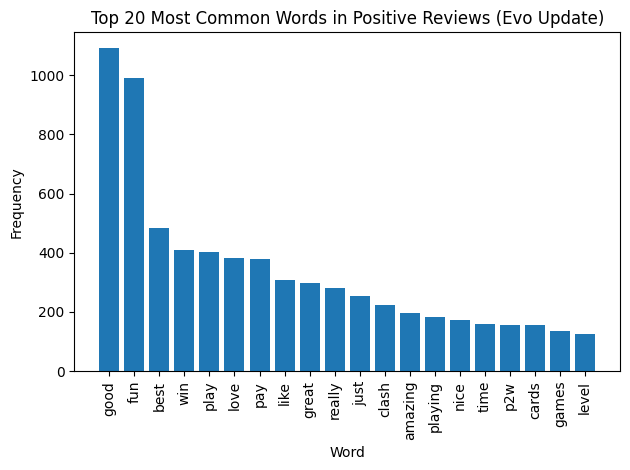

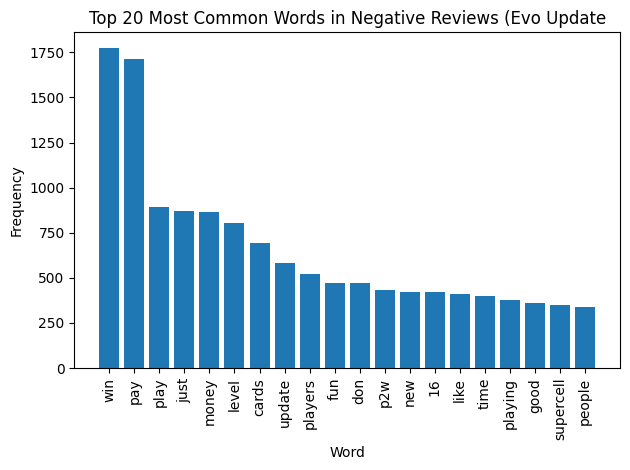

In [ ]:
top_pos = X_pos.head(20)

plt.figure()
plt.bar(top_pos['word'], top_pos['count'])
plt.xticks(rotation=90)
plt.title("Top 20 Most Common Words in Positive Reviews (Evo Update)")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

top_neg = words_neg.head(20)

plt.figure()
plt.bar(top_neg['word'], top_neg['count'])
plt.xticks(rotation=90)
plt.title("Top 20 Most Common Words in Negative Reviews (Evo Update")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
#Trigrams

trigram_vectorizer = CountVectorizer(
    ngram_range=(3,3),
    token_pattern=r"[A-Za-z']+"
)

In [ ]:
#Trigrams for Prelude
X_prelude = trigram_vectorizer.fit_transform(
    positive_reviews_prelude['content'].values.astype('U')
)

trigram_counts_prelude = X_prelude.toarray().sum(axis=0)

trigrams_prelude = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts_prelude
}).sort_values(by='count', ascending=False)

print(trigrams_prelude.head(20))

               trigram  count
282393    this game is   3503
180974  love this game   2452
43119   best game ever   2254
269623   the best game   1929
137295       i love it   1922
65095   clash of clans   1920
137376     i love this   1909
152616     is the best   1253
306292  very good game   1166
2222       a good game   1083
271819     the game is   1018
156402         it is a    986
136939       i like it    849
2403      a great game    759
176005  like this game    713
180821   love the game    677
283182     this is the    667
282984       this is a    646
136988     i like this    632
214766      one of the    604


In [ ]:
X_prelude_neg = trigram_vectorizer.fit_transform(
    negative_reviews_prelude['content'].values.astype('U')
)

trigram_counts_prelude_neg = X_prelude_neg.toarray().sum(axis=0)

trigrams_prelude_neg = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts_prelude_neg
}).sort_values(by='count', ascending=False)

print(trigrams_prelude_neg.head(20))

                  trigram  count
840771       this game is   5255
649439         pay to win   4987
807500        the game is   2283
179887     clash of clans   1594
974175    worst game ever   1261
663304     play this game   1199
872196        to win game    946
410927       in this game    935
7722             a lot of    931
841240    this game sucks    929
357389     hate this game    913
672234  playing this game    902
931948      waste of time    891
410385        in the game    849
987125        you have to    824
386262        i hate this    821
806968       the game and    733
821586     the worst game    707
914524         used to be    692
606702        of the game    689


In [ ]:
#Trigrams for Champions
X_champions = trigram_vectorizer.fit_transform(
    positive_reviews_champions['content'].values.astype('U')
)

trigram_counts_champions = X_champions.toarray().sum(axis=0)

trigrams_champions = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts_champions
}).sort_values(by='count', ascending=False)

print(trigrams_champions.head(20))

                  trigram  count
155390       this game is   1409
122084         pay to win    906
98803      love this game    832
149317        the game is    676
23453      best game ever    620
1156          a good game    590
74335         i love this    582
168557     very good game    540
148109      the best game    522
74285           i love it    365
63867       good game but    361
85196             it is a    332
117454         one of the    326
1236         a great game    293
54122         fun to play    291
83010         is the best    290
115293        of the best    282
98748       love the game    267
155735          this is a    251
126468  playing this game    246


In [ ]:
X_champions_neg = trigram_vectorizer.fit_transform(
    negative_reviews_champions['content'].values.astype('U')
)

trigram_counts_champions_neg = X_champions_neg.toarray().sum(axis=0)

trigrams_champions_neg = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts_champions_neg
}).sort_values(by='count', ascending=False)

print(trigrams_champions_neg.head(20))

                  trigram  count
308002         pay to win   4567
399070       this game is   2488
381859        the game is   1137
414407        to win game    760
435448         used to be    734
314754     play this game    541
319699  playing this game    474
464405    worst game ever    433
414222         to win and    428
4652             a pay to    404
193718       in this game    397
398979      this game for    383
385009     the new update    382
193416        in the game    363
392751        there is no    352
143559         game is so    345
201900          is pay to    336
381543       the game and    335
3653             a lot of    329
287879        of the game    325


In [ ]:
#Trigrams for Evos
X_evos = trigram_vectorizer.fit_transform(
    positive_reviews_evos['content'].values.astype('U')
)

trigram_counts_evos = X_evos.toarray().sum(axis=0)

trigrams_evos = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts_evos
}).sort_values(by='count', ascending=False)

print(trigrams_evos.head(20))

                  trigram  count
151583         pay to win   1976
193936       this game is   1662
122115     love this game   1030
28457      best game ever    864
92768         i love this    758
186474        the game is    715
184839      the best game    688
210042     very good game    654
1459          a good game    600
92694           i love it    525
145768         one of the    380
79845       good game but    372
105810            it is a    363
103216        is the best    341
67694         fun to play    341
157365  playing this game    328
122034      love the game    318
1551         a great game    314
142953        of the best    306
2133             a lot of    301


In [ ]:
X_evos_neg = trigram_vectorizer.fit_transform(
    negative_reviews_evos['content'].values.astype('U')
)

trigram_counts_evos_neg = X_evos_neg.toarray().sum(axis=0)

trigrams_evos_neg = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts_evos_neg
}).sort_values(by='count', ascending=False)

print(trigrams_evos_neg.head(20))

                  trigram  count
406208         pay to win  11092
530198       this game is   3077
550152        to win game   1786
507179        the game is   1703
576297         used to be   1535
184041       free to play    972
415230     play this game    900
6163             a pay to    797
549809         to win and    790
421860  playing this game    789
530144      this game has    631
259355        in the game    627
530095      this game for    578
270386          is pay to    558
259714       in this game    526
450726    ruined the game    520
506743       the game and    516
616061    worst game ever    508
379248        of the game    503
254081       if you don't    500


In [ ]:
#Trigrams for Heros

In [ ]:
X_heros = trigram_vectorizer.fit_transform(
    positive_reviews_heros['content'].values.astype('U')
)

trigram_counts_heros = X_heros.toarray().sum(axis=0)

trigrams_heros = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts_heros
}).sort_values(by='count', ascending=False)

print(trigrams_heros.head(20))

              trigram  count
21512      pay to win    324
27288    this game is    231
4067   best game ever    114
17564  love this game    101
25920   the best game     98
26161     the game is     86
13160     i love this     85
207       a good game     82
13147       i love it     74
29587  very good game     63
14748     is the best     58
30586    why we clash     57
9290      fun to play     56
14857       is why we     54
27416     this is why     54
9954       game is so     53
11258   good game but     46
310          a lot of     46
14666       is so fun     45
17547   love the game     44


In [ ]:
X_heros_neg = trigram_vectorizer.fit_transform(
    negative_reviews_heros['content'].values.astype('U')
)

trigram_counts_heros_neg = X_heros_neg.toarray().sum(axis=0)

trigrams_heros_neg = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts_heros_neg
}).sort_values(by='count', ascending=False)

print(trigrams_heros_neg.head(20))

                 trigram  count
56218         pay to win   1351
72896       this game is    340
69323        the game is    216
75992        to win game    201
24518       free to play    145
79489         used to be    136
75902         to win and    113
57451     play this game     92
61971    ruined the game     83
58429  playing this game     74
26442         game is so     68
72879      this game has     63
956             a pay to     63
37641          is pay to     62
53806         one of the     60
36086       in this game     58
56210        pay to play     58
748             a lot of     57
64288          so pay to     57
69194       the game and     57


**Fightin' Words**




In [5]:
!git clone https://github.com/jmhessel/FightingWords.git

Cloning into 'FightingWords'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 26 (delta 0), reused 0 (delta 0), pack-reused 25 (from 1)
Receiving objects: 100% (26/26), 6.41 KiB | 6.41 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [6]:
from FightingWords import fighting_words_py3

In [7]:
df_positive = df[df["review_category"] == "positive"]

In [8]:
df_negative = df[df["review_category"] == "negative"]

In [9]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

def remove_stopwords(text):
    if not isinstance(text, str):
        return ""
    # Convert text to lowercase
    text = text.lower()
    # Remove non-alphanumeric characters and tokenize
    words = re.findall(r'\b\w+\b', text)
    # Remove stopwords
    filtered_words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(filtered_words)

pos_sample = df_positive.sample(n=175000, random_state=123)
neg_sample = df_negative.sample(n=175000, random_state=123)

# Apply stopword removal
pos_sample['content'] = pos_sample['content'].apply(remove_stopwords)
neg_sample['content'] = neg_sample['content'].apply(remove_stopwords)

small_pos_sample = df_positive.sample(n=50000, random_state=123)
small_neg_sample = df_negative.sample(n=50000, random_state=123)

# Apply stopword removal
small_pos_sample['content'] = small_pos_sample['content'].apply(remove_stopwords)
small_neg_sample['content'] = small_neg_sample['content'].apply(remove_stopwords)


In [10]:
fw = fighting_words_py3.bayes_compare_language(pos_sample['content'].astype(str), neg_sample['content'].astype(str))

Vocab size is 8766
Comparing language...


In [11]:
pd.DataFrame(fw, columns = ['word', 'z-score'])

,word,z-score
0,win,-72.638477
1,pay,-68.605022
2,level,-63.454008
3,money,-53.439982
4,worst,-42.306051
...,...,...
8761,great,114.349366
8762,best,132.201376
8763,love,134.851596
8764,game,149.621044
